# Phase 2 Analysis - Microstructure, Stationarity, Cointegration & Structural Breaks

**Prerequisites (run before opening this notebook):**
```bash
# 1. Docker up
docker-compose up -d
# 2. Migrate DB
uv run alembic upgrade head
# 3. Compute microstructure metrics
uv run python -m data.microstructure
# 4. Run roll diagnostics (generates PNGs)
uv run python research/roll_diagnostics.py
```

**All proxies are OHLCV-derived and are labeled accordingly. True microstructure (intraday/tick) is not available.**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from sqlalchemy import text

from statsmodels.tsa.stattools import adfuller, kpss, coint, zivot_andrews
from statsmodels.tsa.vector_ar.vecm import coint_johansen

from db.session import get_session

plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.4f}'.format)

SPREADS = ['wti_calendar', 'brent_calendar', 'brent_wti']
SPREAD_COLORS = {'wti_calendar': '#00bcd4', 'brent_calendar': '#ff9800', 'brent_wti': '#4caf50'}

COVID_START  = pd.Timestamp('2020-03-01')
COVID_END    = pd.Timestamp('2020-12-31')
UKRAINE_START = pd.Timestamp('2022-02-24')
UKRAINE_END   = pd.Timestamp('2022-12-31')

session = get_session()
print('DB session ready')

DB session ready


In [2]:
def load_spread_series(name: str) -> pd.Series:
    """Load spread values as a date-indexed Series."""
    rows = session.execute(
        text('SELECT date, value FROM spreads WHERE spread_name = :n ORDER BY date'),
        {'n': name}
    ).fetchall()
    s = pd.Series({pd.Timestamp(r[0]): r[1] for r in rows}, name=name)
    return s.sort_index().dropna()

def load_spread_legs(name: str) -> pd.DataFrame:
    """Load leg1_price and leg2_price for a spread."""
    rows = session.execute(
        text('SELECT date, leg1_price, leg2_price FROM spreads WHERE spread_name = :n ORDER BY date'),
        {'n': name}
    ).fetchall()
    df = pd.DataFrame(rows, columns=['date', 'leg1', 'leg2'])
    df['date'] = pd.to_datetime(df['date'])
    return df.set_index('date').dropna()

def shade_regimes(ax):
    ax.axvspan(COVID_START, COVID_END, alpha=0.15, color='red', label='COVID-19')
    ax.axvspan(UKRAINE_START, UKRAINE_END, alpha=0.15, color='orange', label='Russia-Ukraine')

series = {name: load_spread_series(name) for name in SPREADS}
print({k: len(v) for k, v in series.items()})

{'wti_calendar': 2636, 'brent_calendar': 2606, 'brent_wti': 2131}


## Section 0 - Raw Spread Series

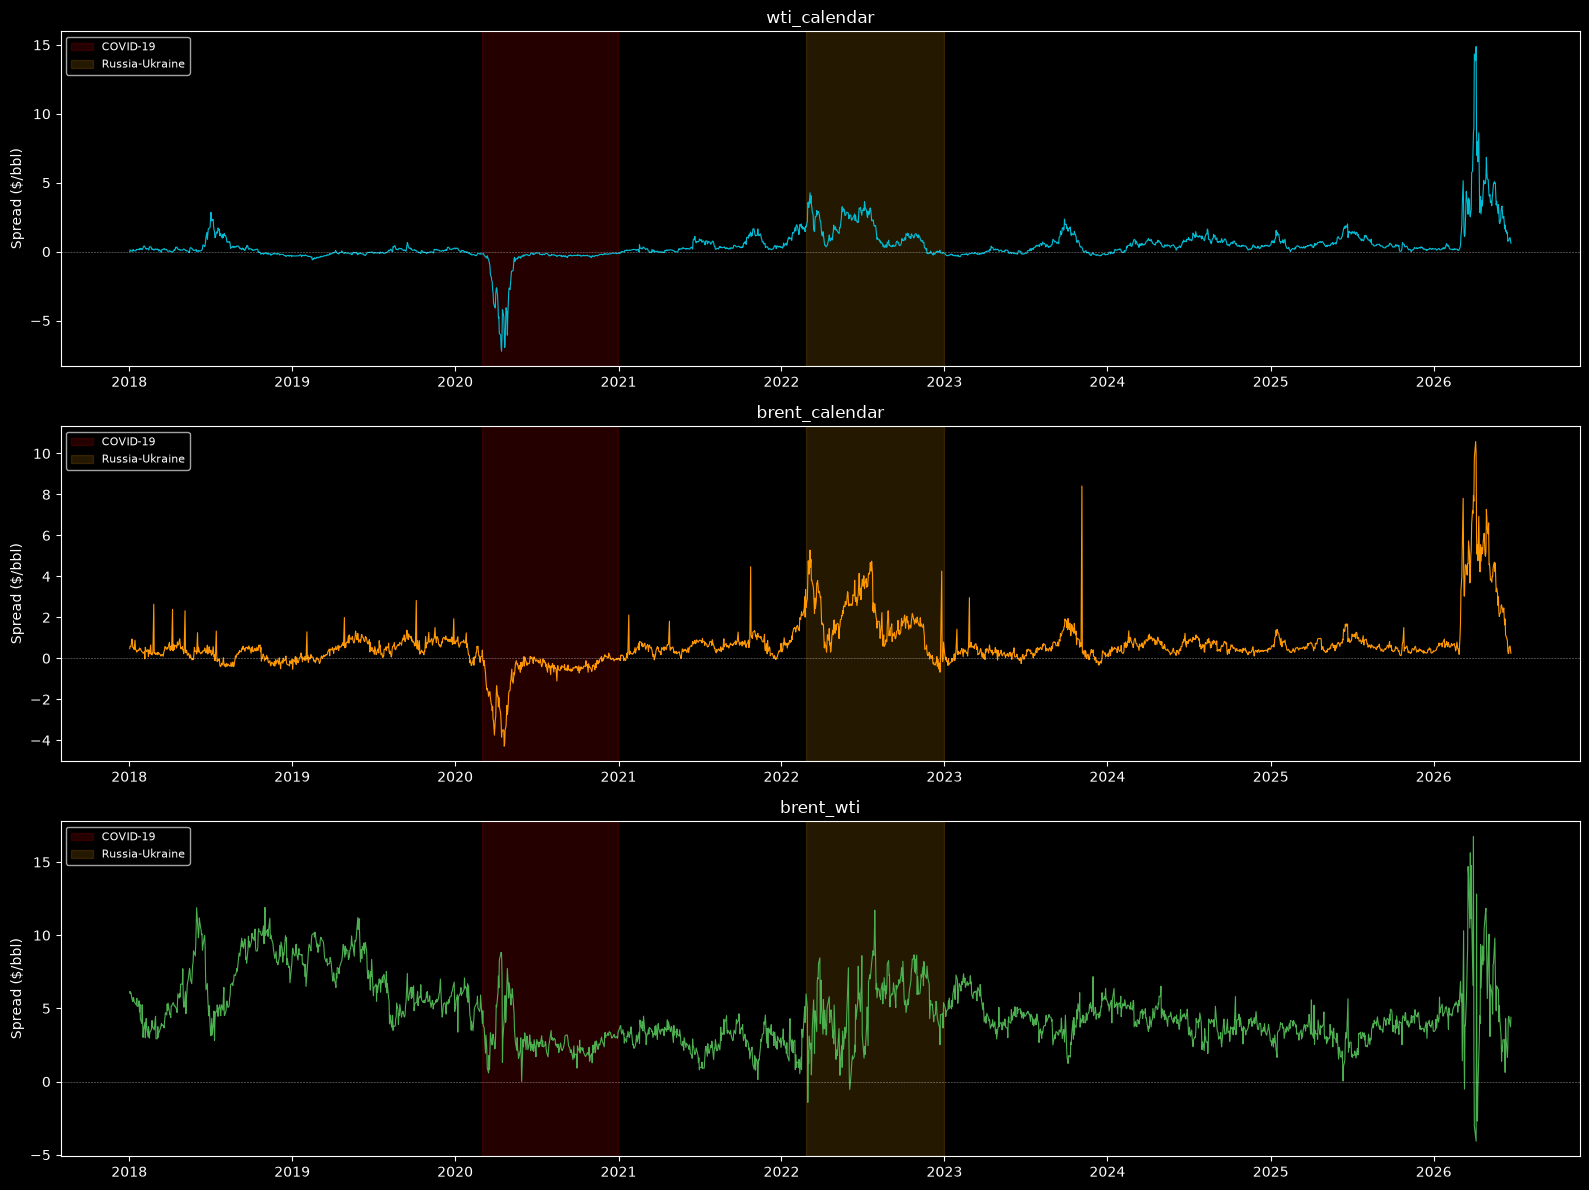

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
for ax, name in zip(axes, SPREADS):
    s = series[name]
    ax.plot(s.index, s.values, color=SPREAD_COLORS[name], linewidth=0.8)
    shade_regimes(ax)
    ax.axhline(0, color='white', linewidth=0.4, linestyle='--', alpha=0.5)
    ax.set_title(name, fontsize=12)
    ax.set_ylabel('Spread ($/bbl)')
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('outputs/spread_series_raw.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 1 - Stationarity Tests (ADF + KPSS)

- **ADF null**: series has a unit root (non-stationary). Reject (p<0.05) → evidence of stationarity.
- **KPSS null**: series is stationary. Reject (p<0.05) → evidence of non-stationarity.
- **I(0) conclusion**: ADF p<0.05 AND KPSS p>0.05 → both agree series is stationary.

In [4]:
def run_adf(s: pd.Series) -> dict:
    res = adfuller(s.values, autolag='AIC')
    return {
        'adf_stat': res[0],
        'adf_p': res[1],
        'adf_lags': res[2],
        'adf_cv_1pct': res[4]['1%'],
        'adf_cv_5pct': res[4]['5%'],
        'adf_cv_10pct': res[4]['10%'],
    }

def run_kpss(s: pd.Series) -> dict:
    res = kpss(s.values, regression='c', nlags='auto')
    return {
        'kpss_stat': res[0],
        'kpss_p': res[1],
        'kpss_cv_10pct': res[3]['10%'],
        'kpss_cv_5pct': res[3]['5%'],
        'kpss_cv_1pct': res[3]['1%'],
    }

stationarity_results = {}
for name in SPREADS:
    s = series[name]
    adf = run_adf(s)
    kpss_res = run_kpss(s)
    stationarity_results[name] = {**adf, **kpss_res}
    adf_conclusion = 'I(0)' if adf['adf_p'] < 0.05 else 'unit root'
    kpss_conclusion = 'stationary' if kpss_res['kpss_p'] > 0.05 else 'non-stationary'
    print(f"\n{name}:")
    print(f"  ADF  stat={adf['adf_stat']:.4f}  p={adf['adf_p']:.4f}  → {adf_conclusion}")
    print(f"  KPSS stat={kpss_res['kpss_stat']:.4f}  p={kpss_res['kpss_p']:.4f}  → {kpss_conclusion}")


wti_calendar:
  ADF  stat=-5.0738  p=0.0000  → I(0)
  KPSS stat=1.4934  p=0.0100  → non-stationary

brent_calendar:
  ADF  stat=-5.7389  p=0.0000  → I(0)
  KPSS stat=1.1999  p=0.0100  → non-stationary

brent_wti:
  ADF  stat=-3.5497  p=0.0068  → I(0)
  KPSS stat=1.4412  p=0.0100  → non-stationary


/var/folders/lj/zsq90r0s6yl8hwcknsphvq1r0000gn/T/ipykernel_18470/3473465394.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(s.values, regression='c', nlags='auto')
/var/folders/lj/zsq90r0s6yl8hwcknsphvq1r0000gn/T/ipykernel_18470/3473465394.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(s.values, regression='c', nlags='auto')
/var/folders/lj/zsq90r0s6yl8hwcknsphvq1r0000gn/T/ipykernel_18470/3473465394.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(s.values, regression='c', nlags='auto')


In [5]:
# Summary table
rows = []
for name, r in stationarity_results.items():
    i_d = 'I(0)' if r['adf_p'] < 0.05 and r['kpss_p'] > 0.05 else ('mixed' if r['adf_p'] < 0.05 or r['kpss_p'] > 0.05 else 'I(1)')
    rows.append({
        'spread': name,
        'ADF stat': r['adf_stat'],
        'ADF p': r['adf_p'],
        'ADF I(0)?': r['adf_p'] < 0.05,
        'KPSS stat': r['kpss_stat'],
        'KPSS p': r['kpss_p'],
        'KPSS stat?': r['kpss_p'] > 0.05,
        'I(d)': i_d,
    })
pd.DataFrame(rows).set_index('spread')

,ADF stat,ADF p,ADF I(0)?,KPSS stat,KPSS p,KPSS stat?,I(d)
spread,,,,,,,
wti_calendar,-5.0738,0.0000,True,1.4934,0.0100,False,mixed
brent_calendar,-5.7389,0.0000,True,1.1999,0.0100,False,mixed
brent_wti,-3.5497,0.0068,True,1.4412,0.0100,False,mixed


## Section 2 - Cointegration (Brent vs WTI front-month)

In [6]:
legs = load_spread_legs('brent_wti')
leg1 = legs['leg1'].values  # Brent M1
leg2 = legs['leg2'].values  # WTI M1

# Engle-Granger
eg_stat, eg_p, eg_cvs = coint(leg1, leg2)
print(f"Engle-Granger: stat={eg_stat:.4f}, p={eg_p:.4f}")
print(f"  Critical values (1%, 5%, 10%): {eg_cvs}")

# OLS hedge ratio
beta_ols = np.cov(leg1, leg2)[0, 1] / np.var(leg2)
print(f"  OLS hedge ratio β = {beta_ols:.4f}")

Engle-Granger: stat=-3.5506, p=0.0282
  Critical values (1%, 5%, 10%): [-3.90158913 -3.3390001  -3.04644177]
  OLS hedge ratio β = 1.0013


In [7]:
# Johansen test
mat = np.column_stack([leg1, leg2])
jo = coint_johansen(mat, det_order=0, k_ar_diff=1)

print("Johansen Trace Test:")
print(f"  H0: r=0   trace stat={jo.lr1[0]:.4f}   CV(95%)={jo.cvt[0, 1]:.4f}   reject: {jo.lr1[0] > jo.cvt[0, 1]}")
print(f"  H0: r≤1   trace stat={jo.lr1[1]:.4f}   CV(95%)={jo.cvt[1, 1]:.4f}   reject: {jo.lr1[1] > jo.cvt[1, 1]}")

print("\nJohansen Max-Eigenvalue Test:")
print(f"  H0: r=0   eigen stat={jo.lr2[0]:.4f}   CV(95%)={jo.cvm[0, 1]:.4f}   reject: {jo.lr2[0] > jo.cvm[0, 1]}")
print(f"  H0: r≤1   eigen stat={jo.lr2[1]:.4f}   CV(95%)={jo.cvm[1, 1]:.4f}   reject: {jo.lr2[1] > jo.cvm[1, 1]}")

print(f"\nJohansen hedge ratio (eigenvector): {jo.evec[:, 0]}")

Johansen Trace Test:
  H0: r=0   trace stat=67.6854   CV(95%)=15.4943   reject: True
  H0: r≤1   trace stat=6.0511   CV(95%)=3.8415   reject: True

Johansen Max-Eigenvalue Test:
  H0: r=0   eigen stat=61.6343   CV(95%)=14.2639   reject: True
  H0: r≤1   eigen stat=6.0511   CV(95%)=3.8415   reject: True

Johansen hedge ratio (eigenvector): [ 0.45133725+0.j -0.45596668+0.j]


## Section 3 - Rolling Half-Life of Mean Reversion

AR(1) regression: `ΔS_t = a + b·S_{t-1} + ε`  
Half-life = `-ln(2) / b`  (defined when b < 0, i.e. mean-reverting)

In [8]:
def rolling_half_life(s: pd.Series, window: int = 252, step: int = 21) -> pd.DataFrame:
    """Compute rolling AR(1) half-life. window in bars, step in bars."""
    records = []
    arr = s.values
    dS = np.diff(arr)
    S_lag = arr[:-1]
    idx = s.index[1:]  # aligned with dS

    for i in range(window, len(dS) + 1, step):
        sl_dS = dS[i - window:i]
        sl_lag = S_lag[i - window:i]
        mask = np.isfinite(sl_dS) & np.isfinite(sl_lag)
        if mask.sum() < window // 2:
            continue
        coeffs = np.polyfit(sl_lag[mask], sl_dS[mask], 1)
        b = coeffs[0]
        hl = -np.log(2) / b if b < 0 else np.nan
        records.append({'date': idx[i - 1], 'b': b, 'half_life': hl})

    return pd.DataFrame(records).set_index('date')

hl_results = {name: rolling_half_life(series[name]) for name in SPREADS}

for name, df in hl_results.items():
    hl = df['half_life'].dropna()
    print(f"{name}: mean HL={hl.mean():.1f}d  p25={hl.quantile(0.25):.1f}d  p75={hl.quantile(0.75):.1f}d  b>=0: {(df['b'] >= 0).mean():.1%}")

wti_calendar: mean HL=24.6d  p25=15.5d  p75=31.3d  b>=0: 2.6%
brent_calendar: mean HL=7.1d  p25=2.3d  p75=8.0d  b>=0: 0.0%
brent_wti: mean HL=4.9d  p25=2.9d  p75=5.8d  b>=0: 0.0%


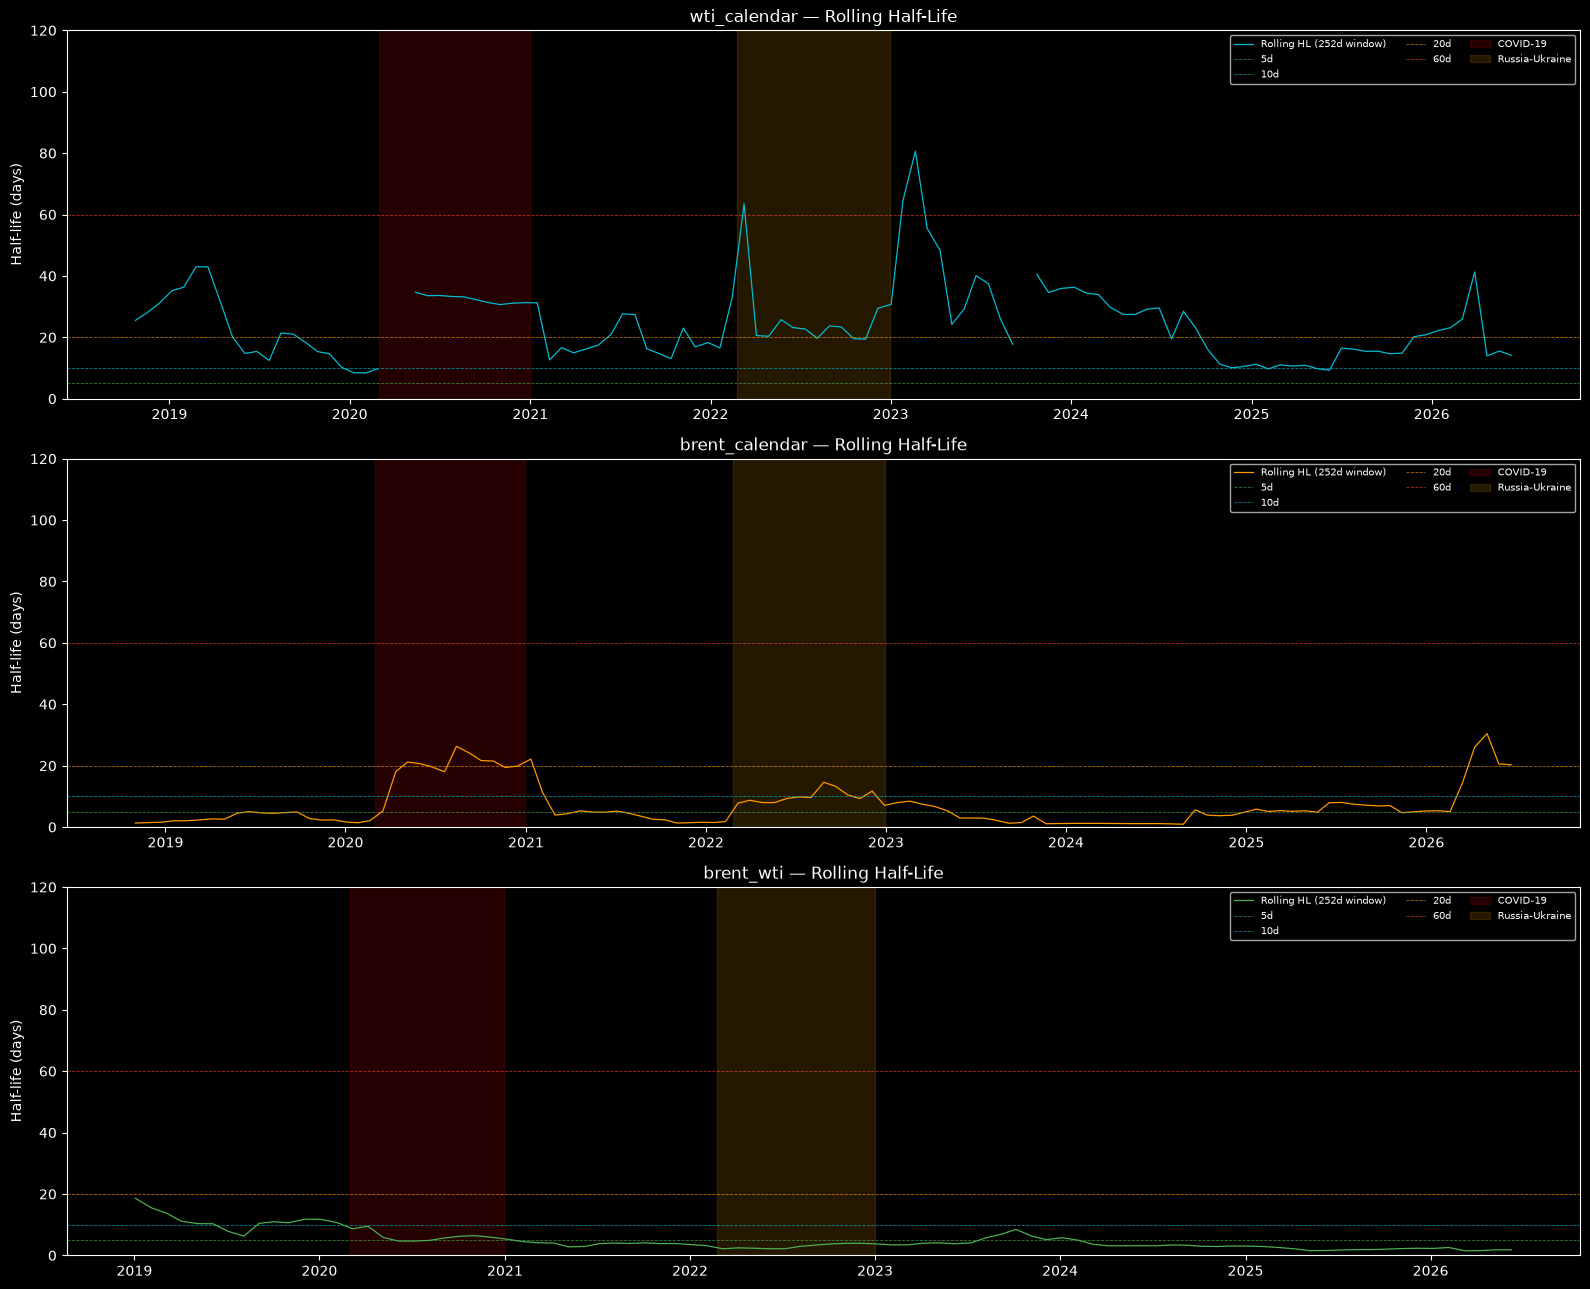

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)
ref_lines = [5, 10, 20, 60]
ref_colors = ['#4caf50', '#00bcd4', '#ff9800', '#f44336']

for ax, name in zip(axes, SPREADS):
    df = hl_results[name]
    hl = df['half_life'].clip(upper=120)  # cap display at 120 days
    ax.plot(hl.index, hl.values, color=SPREAD_COLORS[name], linewidth=0.9, label='Rolling HL (252d window)')
    for ref, col in zip(ref_lines, ref_colors):
        ax.axhline(ref, color=col, linewidth=0.6, linestyle='--', alpha=0.7, label=f'{ref}d')
    shade_regimes(ax)
    ax.set_ylim(0, 120)
    ax.set_title(f'{name} - Rolling Half-Life', fontsize=12)
    ax.set_ylabel('Half-life (days)')
    ax.legend(fontsize=7, loc='upper right', ncol=3)

plt.tight_layout()
plt.savefig('outputs/rolling_half_life.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 - Structural Breaks (Zivot-Andrews + Rolling ADF)

In [10]:
def run_zivot_andrews(s: pd.Series) -> dict:
    res = zivot_andrews(s.values, maxlag=12, regression='ct', autolag='AIC')
    # Returns: (zastat, pvalue, cvdict, baselag, basebreakpoint)
    stat, p, cvs, lag, bp_idx = res
    break_date = s.index[bp_idx] if bp_idx < len(s) else None
    return {
        'za_stat': stat,
        'za_p': p,
        'za_cv_5pct': cvs['5%'],
        'za_lag': lag,
        'break_date': break_date,
    }

za_results = {}
for name in SPREADS:
    print(f"Running Zivot-Andrews for {name} ...")
    res = run_zivot_andrews(series[name])
    za_results[name] = res
    print(f"  stat={res['za_stat']:.4f}  p={res['za_p']:.4f}  break={res['break_date'].date() if res['break_date'] else 'N/A'}")

Running Zivot-Andrews for wti_calendar ...
  stat=-5.3896  p=0.0200  break=2020-04-27
Running Zivot-Andrews for brent_calendar ...


  stat=-4.7337  p=0.1261  break=2023-11-05
Running Zivot-Andrews for brent_wti ...
  stat=-6.2129  p=0.0016  break=2019-05-31


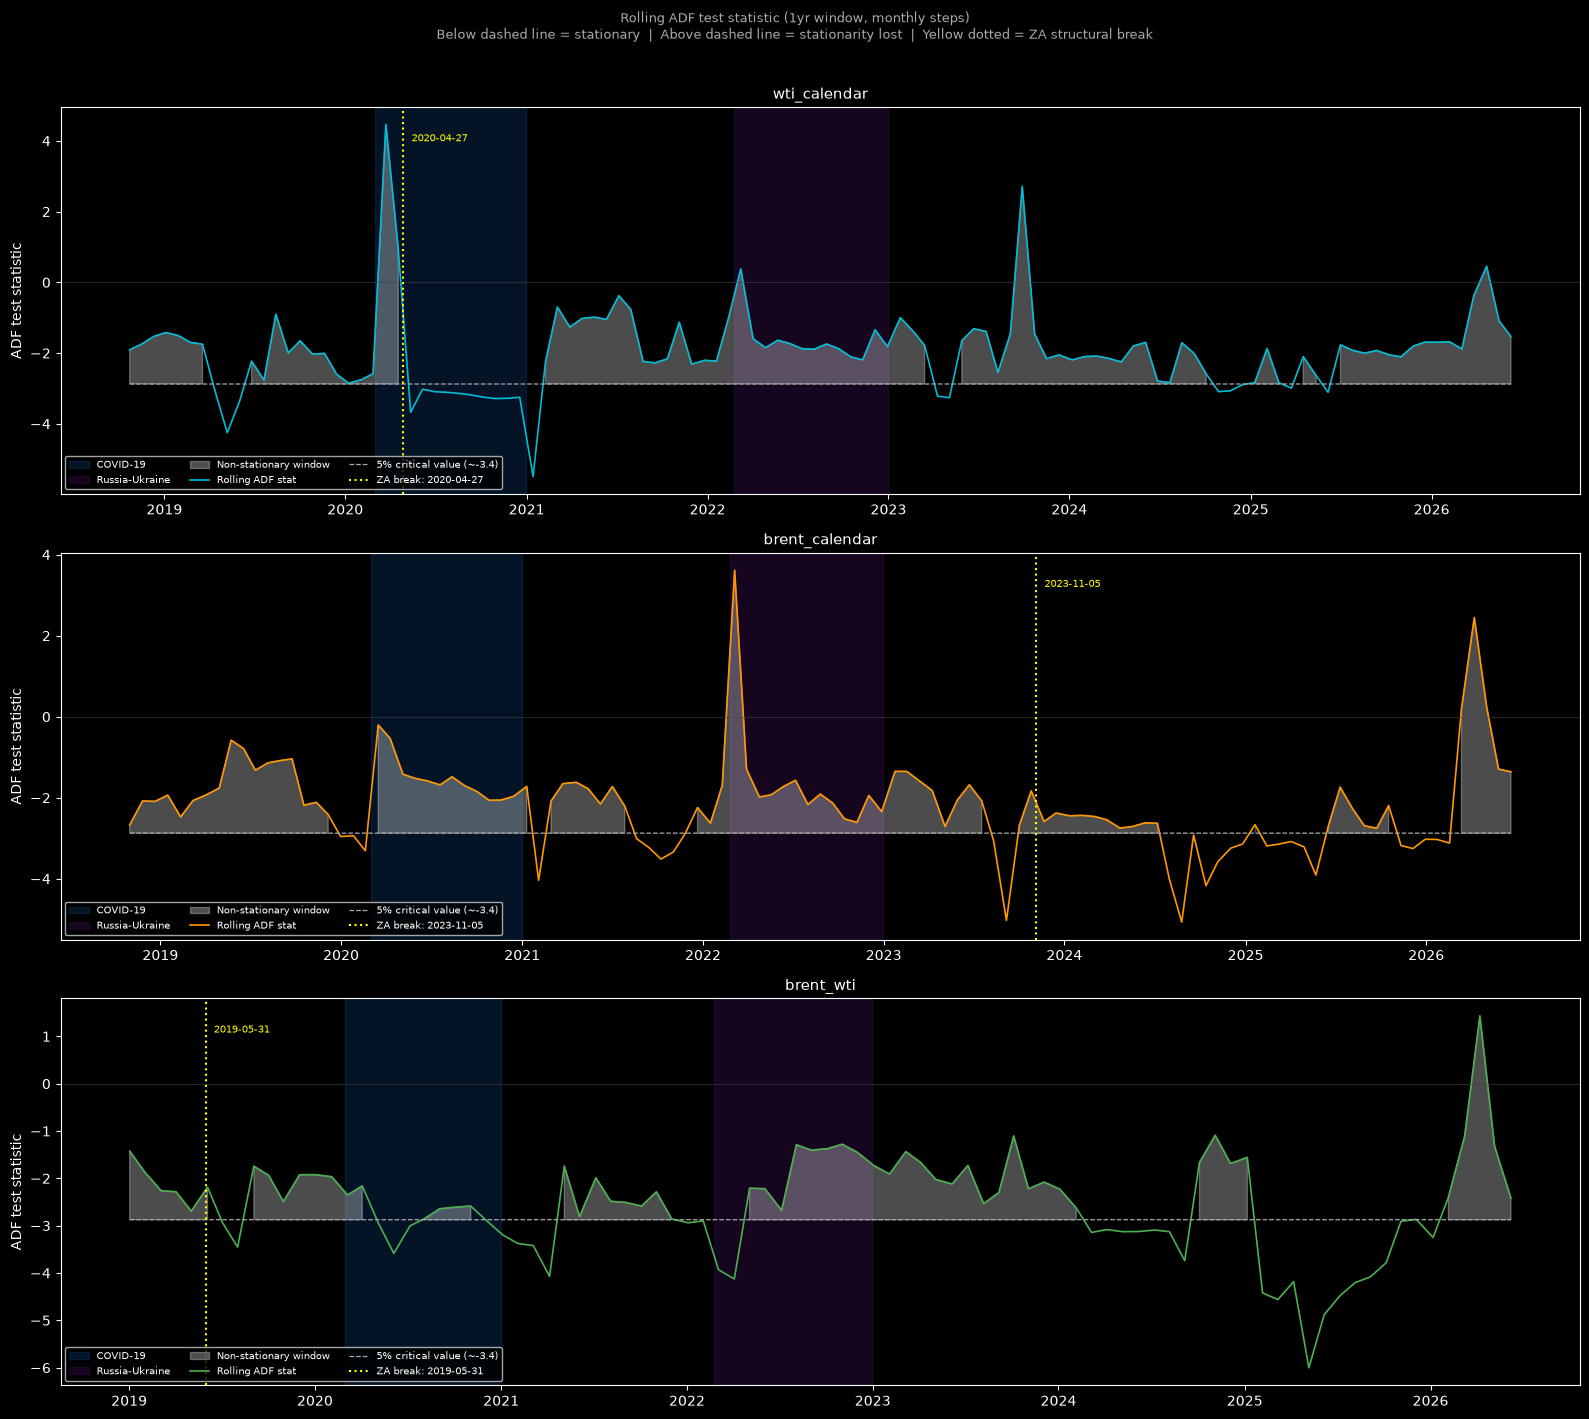

In [ ]:
def rolling_adf_stat(s: pd.Series, window: int = 252, step: int = 21) -> pd.DataFrame:
    """Rolling ADF statistic. window=252 (1yr) gives first point ~1yr into data, capturing 2019 breaks."""
    records = []
    arr = s.values
    for i in range(window, len(arr) + 1, step):
        sl = arr[i - window:i]
        if not np.all(np.isfinite(sl)):
            continue
        res = adfuller(sl, autolag='AIC')
        records.append({'date': s.index[i - 1], 'adf_stat': res[0], 'cv_5pct': res[4]['5%']})
    return pd.DataFrame(records).set_index('date')

rolling_adf = {name: rolling_adf_stat(series[name]) for name in SPREADS}

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle(
    'Rolling ADF test statistic (1yr window, monthly steps)\n'
    'Below dashed line = stationary  |  Above dashed line = stationarity lost  |  Yellow dotted = ZA structural break',
    fontsize=9, color='#aaaaaa', y=1.01
)

for ax, name in zip(axes, SPREADS):
    df = rolling_adf[name]
    color = SPREAD_COLORS[name]

    # Regime shading - use blue/purple, nothing red
    ax.axvspan(COVID_START, COVID_END, alpha=0.20, color='#1565C0', label='COVID-19')          # blue
    ax.axvspan(UKRAINE_START, UKRAINE_END, alpha=0.20, color='#6A1B9A', label='Russia-Ukraine') # purple

    # Fill between ADF line and critical value only when non-stationary (above CV)
    # Use white fill so it reads as "warning" without being red
    ax.fill_between(
        df.index, df['adf_stat'], df['cv_5pct'],
        where=df['adf_stat'] > df['cv_5pct'],
        alpha=0.3, color='white', label='Non-stationary window'
    )

    ax.plot(df.index, df['adf_stat'], color=color, linewidth=1.2, label='Rolling ADF stat')
    ax.plot(df.index, df['cv_5pct'], color='#aaaaaa', linewidth=0.9, linestyle='--', label='5% critical value (~-3.4)')
    ax.axhline(0, color='#444444', linewidth=0.4)

    za_break = za_results[name]['break_date']
    if za_break and za_break >= df.index[0]:
        ax.axvline(za_break, color='yellow', linewidth=1.5, linestyle=':', label=f'ZA break: {za_break.date()}')
        ax.annotate(
            f'{za_break.date()}',
            xy=(za_break, df['adf_stat'].max()),
            xytext=(6, -12), textcoords='offset points',
            color='yellow', fontsize=7
        )
    elif za_break:
        ax.text(0.01, 0.06, f'ZA break: {za_break.date()} (before chart range)',
                transform=ax.transAxes, color='yellow', fontsize=7)

    ax.set_title(name, fontsize=11)
    ax.set_ylabel('ADF test statistic')
    ax.legend(fontsize=7, loc='lower left', ncol=3)

plt.tight_layout()
plt.savefig('outputs/rolling_adf.png', dpi=150, bbox_inches='tight')
plt.show()

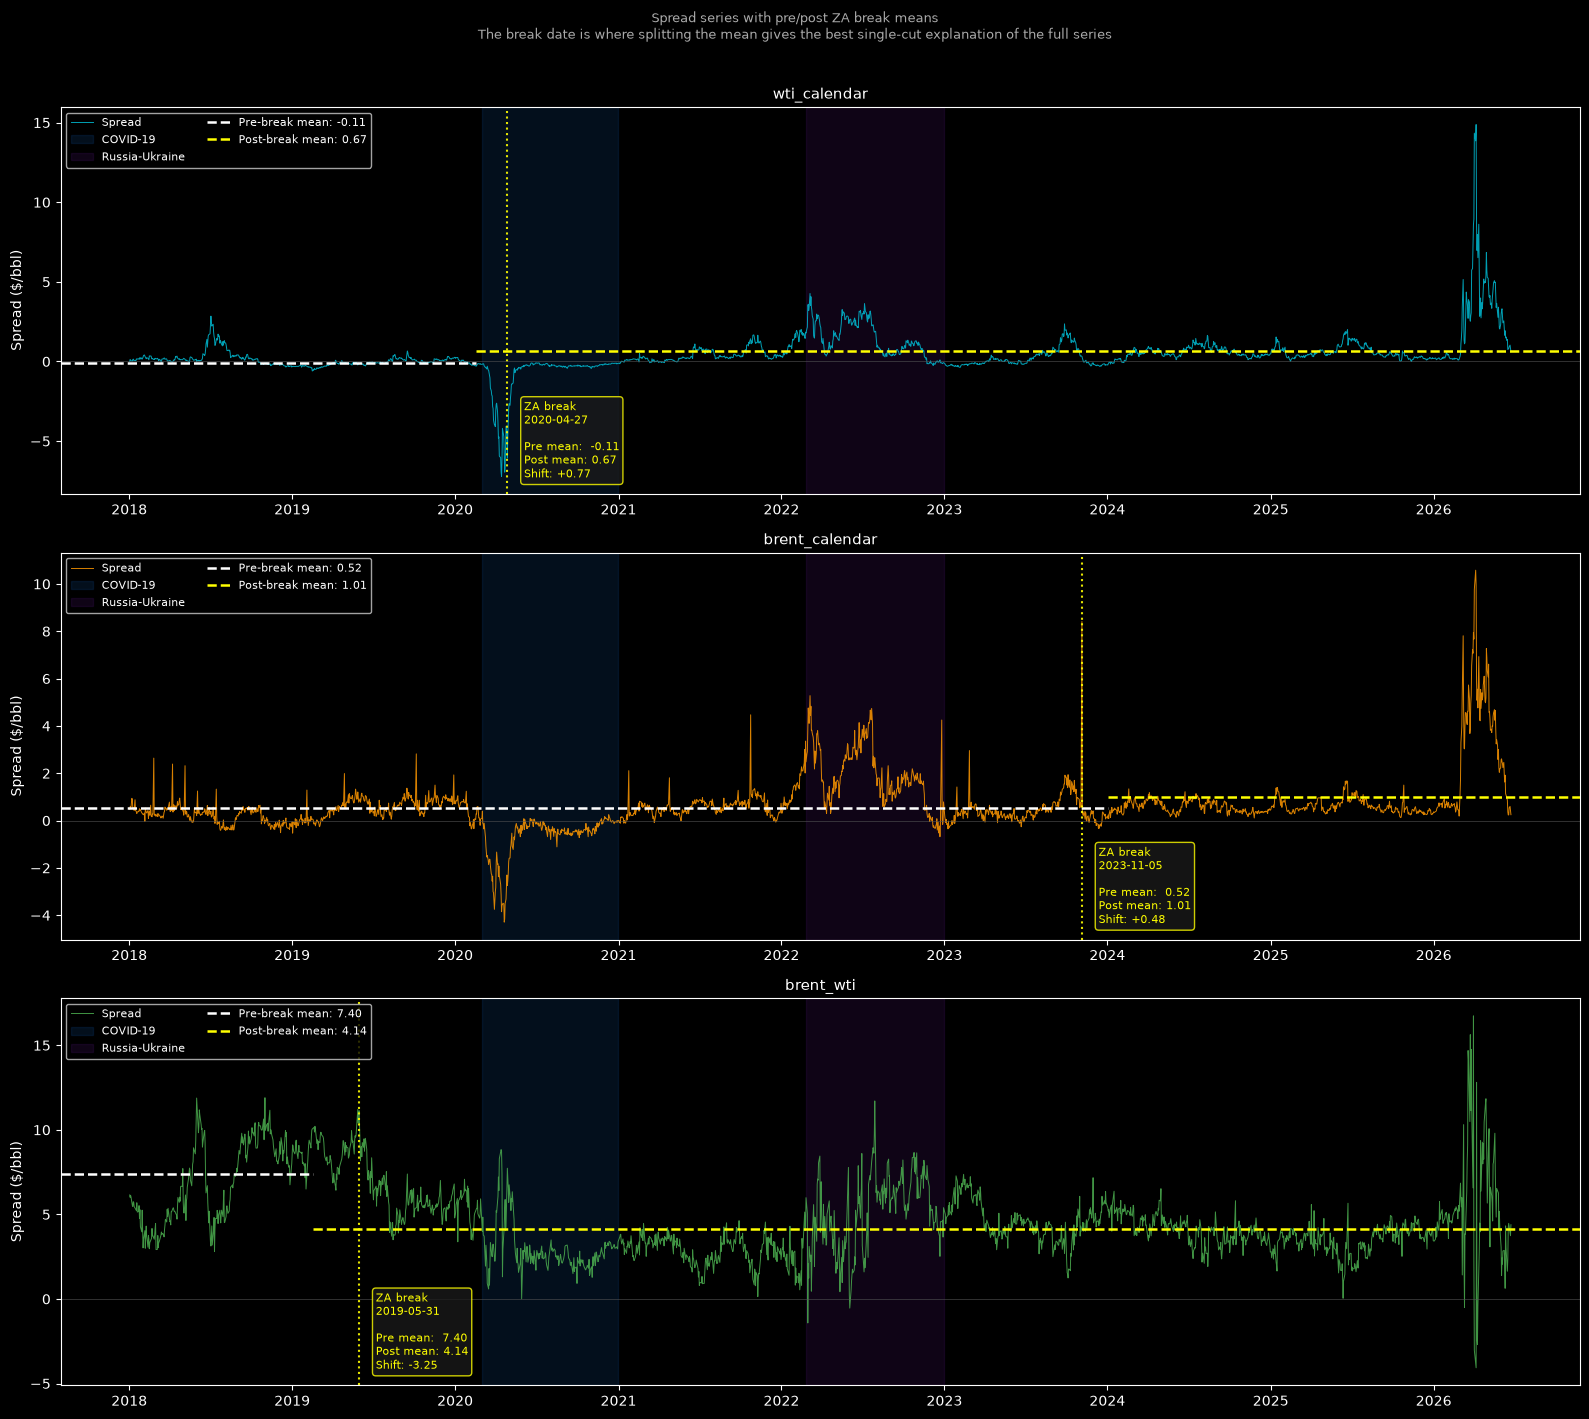

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle(
    'Spread series with pre/post ZA break means\n'
    'The break date is where splitting the mean gives the best single-cut explanation of the full series',
    fontsize=9, color='#aaaaaa', y=1.01
)

for ax, name in zip(axes, SPREADS):
    s = series[name]
    color = SPREAD_COLORS[name]
    za_break = za_results[name]['break_date']

    ax.plot(s.index, s.values, color=color, linewidth=0.7, alpha=0.85, label='Spread')

    # Regime shading
    ax.axvspan(COVID_START, COVID_END, alpha=0.15, color='#1565C0', label='COVID-19')
    ax.axvspan(UKRAINE_START, UKRAINE_END, alpha=0.15, color='#6A1B9A', label='Russia-Ukraine')

    if za_break:
        pre  = s[s.index <  za_break]
        post = s[s.index >= za_break]
        pre_mean  = pre.mean()
        post_mean = post.mean()

        ax.axhline(pre_mean,  xmin=0,
                   xmax=(za_break - s.index[0]) / (s.index[-1] - s.index[0]),
                   color='white', linewidth=1.8, linestyle='--', label=f'Pre-break mean: {pre_mean:.2f}')
        ax.axhline(post_mean, xmin=(za_break - s.index[0]) / (s.index[-1] - s.index[0]),
                   xmax=1,
                   color='yellow', linewidth=1.8, linestyle='--', label=f'Post-break mean: {post_mean:.2f}')

        ax.axvline(za_break, color='yellow', linewidth=1.5, linestyle=':', alpha=0.9)
        ax.annotate(
            f'ZA break\n{za_break.date()}\n\nPre mean:  {pre_mean:.2f}\nPost mean: {post_mean:.2f}\nShift: {post_mean - pre_mean:+.2f}',
            xy=(za_break, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else s.min()),
            xytext=(12, 12), textcoords='offset points',
            color='yellow', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a1a', edgecolor='yellow', alpha=0.8)
        )

    ax.axhline(0, color='#555555', linewidth=0.4)
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('Spread ($/bbl)')
    ax.legend(fontsize=8, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig('outputs/spread_za_means.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Write structural_breaks.json
import datetime

breaks = {}
contexts = {
    'wti_calendar': 'WTI demand/supply shock - COVID collapse or Cushing storage crisis',
    'brent_calendar': 'Brent term structure regime change',
    'brent_wti': 'Structural shift in Brent-WTI differential (Russia-Ukraine / US export capacity)',
}

for name, res in za_results.items():
    bd = res['break_date']
    breaks[name] = [{
        'date': str(bd.date()) if bd else None,
        'test': 'zivot_andrews',
        'stat': float(res['za_stat']),
        'p_value': float(res['za_p']),
        'cv_5pct': float(res['za_cv_5pct']),
        'context': contexts.get(name, ''),
    }]

out_path = Path('../research/structural_breaks.json')
out_path.write_text(json.dumps(breaks, indent=2))
print('Written:', out_path.resolve())
print(json.dumps(breaks, indent=2))

Written: /Users/nick/Documents/Apps/commodity-stat-arb/research/structural_breaks.json
{
  "wti_calendar": [
    {
      "date": "2020-04-27",
      "test": "zivot_andrews",
      "stat": -5.389617593314789,
      "p_value": 0.02001413219976364,
      "cv_5pct": -5.07332,
      "context": "WTI demand/supply shock \u2014 COVID collapse or Cushing storage crisis"
    }
  ],
  "brent_calendar": [
    {
      "date": "2023-11-05",
      "test": "zivot_andrews",
      "stat": -4.733667654149529,
      "p_value": 0.1261189526233492,
      "cv_5pct": -5.07332,
      "context": "Brent term structure regime change"
    }
  ],
  "brent_wti": [
    {
      "date": "2019-05-31",
      "test": "zivot_andrews",
      "stat": -6.212908417926639,
      "p_value": 0.0016089136487477994,
      "cv_5pct": -5.07332,
      "context": "Structural shift in Brent-WTI differential (Russia-Ukraine / US export capacity)"
    }
  ]
}


## Section 5 - Summary Table (for research/notes.md)

In [14]:
rows = []
for name in SPREADS:
    sr = stationarity_results[name]
    hl_df = hl_results[name]['half_life'].dropna()
    za = za_results[name]
    i_d = 'I(0)' if sr['adf_p'] < 0.05 and sr['kpss_p'] > 0.05 else 'mixed/I(1)'
    rows.append({
        'Spread': name,
        'ADF p': f"{sr['adf_p']:.4f}",
        'KPSS p': f"{sr['kpss_p']:.4f}",
        'I(d)': i_d,
        'Mean HL (days)': f"{hl_df.mean():.1f}",
        'HL p25': f"{hl_df.quantile(0.25):.1f}",
        'HL p75': f"{hl_df.quantile(0.75):.1f}",
        'ZA break': str(za['break_date'].date()) if za['break_date'] else 'N/A',
        'ZA p': f"{za['za_p']:.4f}",
    })

summary = pd.DataFrame(rows).set_index('Spread')
print('=== SUMMARY TABLE (copy to notes.md) ===')
print(summary.to_string())
summary

=== SUMMARY TABLE (copy to notes.md) ===
                 ADF p  KPSS p        I(d) Mean HL (days) HL p25 HL p75    ZA break    ZA p
Spread                                                                                     
wti_calendar    0.0000  0.0100  mixed/I(1)           24.6   15.5   31.3  2020-04-27  0.0200
brent_calendar  0.0000  0.0100  mixed/I(1)            7.1    2.3    8.0  2023-11-05  0.1261
brent_wti       0.0068  0.0100  mixed/I(1)            4.9    2.9    5.8  2019-05-31  0.0016


,ADF p,KPSS p,I(d),Mean HL (days),HL p25,HL p75,ZA break,ZA p
Spread,,,,,,,,
wti_calendar,0.0000,0.0100,mixed/I(1),24.6,15.5,31.3,2020-04-27,0.0200
brent_calendar,0.0000,0.0100,mixed/I(1),7.1,2.3,8.0,2023-11-05,0.1261
brent_wti,0.0068,0.0100,mixed/I(1),4.9,2.9,5.8,2019-05-31,0.0016


In [15]:
# Cointegration summary
print('=== COINTEGRATION (brent_wti legs) ===')
print(f'Engle-Granger p = {eg_p:.4f}  → {"cointegrated" if eg_p < 0.05 else "NOT cointegrated"} at 5%')
print(f'OLS hedge ratio β = {beta_ols:.4f}')
print(f'Johansen trace: r=0 reject={jo.lr1[0] > jo.cvt[0,1]}, r≤1 reject={jo.lr1[1] > jo.cvt[1,1]}')

session.close()
print('\nSession closed.')

=== COINTEGRATION (brent_wti legs) ===
Engle-Granger p = 0.0282  → cointegrated at 5%
OLS hedge ratio β = 1.0013
Johansen trace: r=0 reject=True, r≤1 reject=True

Session closed.
